# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

In [ ]:
%load_ext autoreload
%autoreload 2

In [16]:
# Клонируем свой форк репозитория с GitHub
!git clone https://github.com/QFXzZ/2025-Selyutin-TimeSeriesCourse.git

Cloning into '2025-Selyutin-TimeSeriesCourse'...
remote: Enumerating objects: 297, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (60/60), done.
remote: Total 297 (delta 14), reused 3 (delta 3), pack-reused 234 (from 2)
Receiving objects: 100% (297/297), 242.36 MiB | 19.90 MiB/s, done.
Resolving deltas: 100% (29/29), done.
Updating files: 100% (198/198), done.


In [17]:
%cd 2025-Selyutin-TimeSeriesCourse/practice/"05 Snippets"

/content/2025-Selyutin-TimeSeriesCourse/practice/05 Snippets/2025-Selyutin-TimeSeriesCourse/practice/05 Snippets


In [18]:
!ls

'05 Snippets.ipynb'   datasets	 modules


Импорт библиотек и модулей

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from modules.snippets import *
from scipy import signal
from stumpy import snippets
import pandas as pd

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

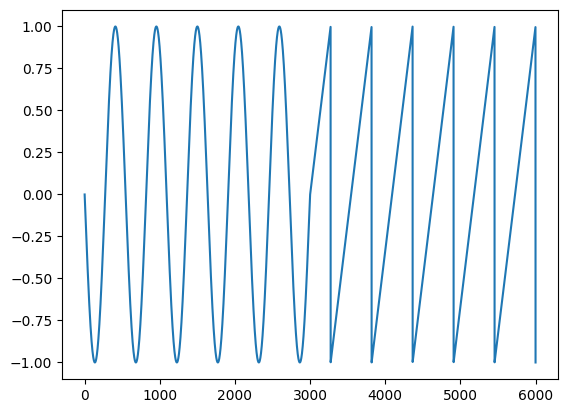

In [20]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [21]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


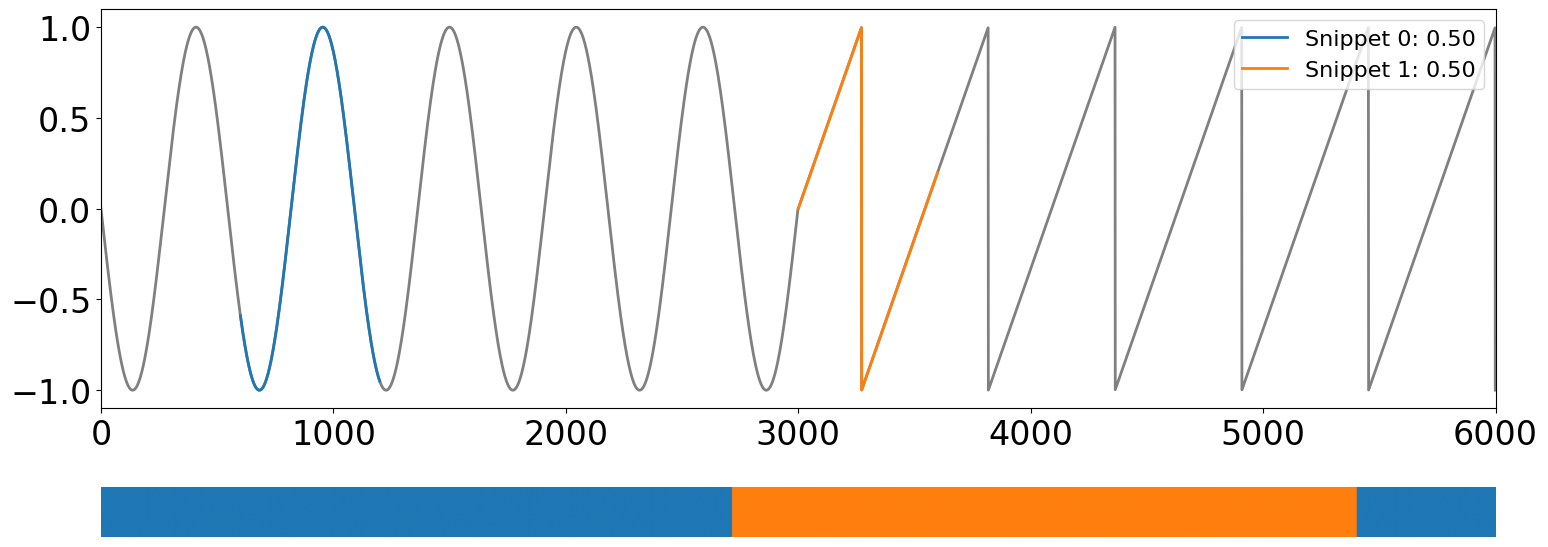

<Axes: >

In [22]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [23]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

Saving subject101.dat to subject101.dat


In [24]:
import pandas as pd

# Определяем названия колонок PAMAP2 (54 колонки)
cols = ["timestamp", "activityID", "heart_rate"] + \
       ["temp_hand"] + ["acc16_hand_x","acc16_hand_y","acc16_hand_z"] + \
       ["acc6_hand_x","acc6_hand_y","acc6_hand_z"] + \
       ["gyro_hand_x","gyro_hand_y","gyro_hand_z"] + \
       ["mag_hand_x","mag_hand_y","mag_hand_z"] + \
       ["orient1_hand","orient2_hand","orient3_hand","orient4_hand"] + \
       ["temp_chest"] + ["acc16_chest_x","acc16_chest_y","acc16_chest_z"] + \
       ["acc6_chest_x","acc6_chest_y","acc6_chest_z"] + \
       ["gyro_chest_x","gyro_chest_y","gyro_chest_z"] + \
       ["mag_chest_x","mag_chest_y","mag_chest_z"] + \
       ["orient1_chest","orient2_chest","orient3_chest","orient4_chest"] + \
       ["temp_ankle"] + ["acc16_ankle_x","acc16_ankle_y","acc16_ankle_z"] + \
       ["acc6_ankle_x","acc6_ankle_y","acc6_ankle_z"] + \
       ["gyro_ankle_x","gyro_ankle_y","gyro_ankle_z"] + \
       ["mag_ankle_x","mag_ankle_y","mag_ankle_z"] + \
       ["orient1_ankle","orient2_ankle","orient3_ankle","orient4_ankle"]

In [25]:
# Чтение .dat файла
df = pd.read_csv(filename, sep=r"\s+", header=None, names=cols, na_values=["NaN"])

In [11]:
# Параметры фильтрации
start_time = 1790
end_time = 1930

# Фильтруем DataFrame по timestamp
df_interval = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

# Берём временной ряд gyro_y Hand IMU
ts = df_interval['gyro_hand_y'].to_numpy()
timestamps = df_interval['timestamp'].to_numpy()

In [12]:
# Параметры поиска сниппетов
m = 600         # длина подпоследовательности
k = 3           # сколько топ-k сниппетов ищем
percentage = 0.5  # процент схожести

In [13]:
snp = snippets(ts, m=m, k=k, percentage=percentage)

Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

600


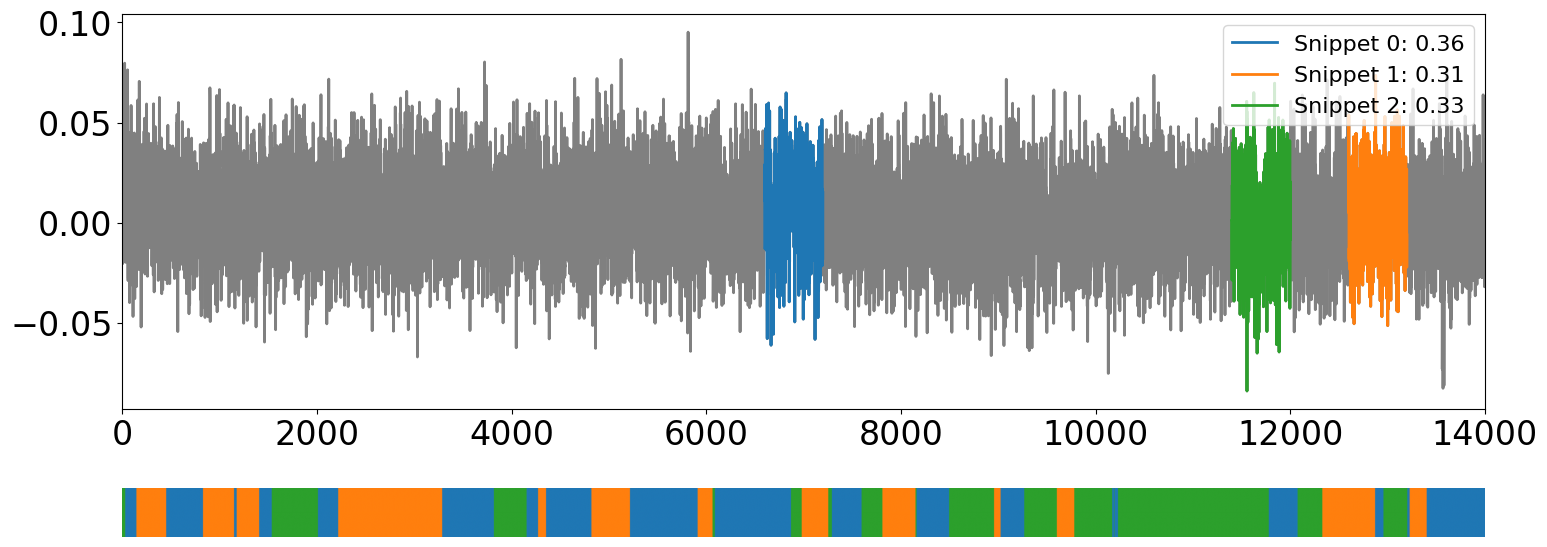

<Axes: >

In [14]:
# INSERT YOUR CODE
plot_snippets(ts, snp)

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [15]:
# INSERT YOUR CODE

snippet_indices = snp[1]   # стартовые индексы сниппетов
snippet_labels = snp[3]    # расстояние/оценка паттерна
snippet_regimes = snp[5]   # (label, start, end)

m = snp[0].shape[0]  # длина сниппета

accuracies = []

for i, start_idx in enumerate(snippet_indices):
    end_idx = start_idx + m
    # Извлекаем activityID для этого сниппета
    activities = df_interval['activityID'].iloc[start_idx:end_idx].to_numpy()

    # Определяем основную активность (мода)
    if len(activities) == 0:
        continue
    main_activity = np.bincount(activities.astype(int)).argmax()

    # Считаем, сколько точек совпадает с основной активностью
    correct = np.sum(activities == main_activity)
    acc = correct / len(activities)
    accuracies.append(acc)

    print(f"Snippet {i}: основная активность = {main_activity}, точность = {acc:.2f}")

# Средняя точность по всем сниппетам
print(f"\nСредняя точность сниппетов: {np.mean(accuracies):.2f}")


Snippet 0: основная активность = 9, точность = 1.00
Snippet 1: основная активность = 9, точность = 1.00
Snippet 2: основная активность = 9, точность = 1.00

Средняя точность сниппетов: 1.00


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Сниппеты - это типичные подпоследовательности во временном ряде, которые повторяются несколько раз. Алгоритм snippets() автоматически ищет повторяющиеся паттерны в ряде, не зная заранее, к какой активности они относятся. Каждый сниппет характеризуется длиной m и стартовым индексом в ряде, где он встречается.

В выбранном временном интервале (1790–1930 сек) исходный ряд гироскопа Hand Y имел только один повторяющийся паттерн, который соответствует активности watching TV.

Алгоритм ищет наиболее типичные подпоследовательности, поэтому все три топ‑k сниппета совпали с одним и тем же паттерном.

Для каждого сниппета все точки подпоследовательности соответствуют одной активности (activityID = 9).

Это говорит о том, что найденные сниппеты идеально отражают исходную разметку активности, т.е. алгоритм не ошибся в определении повторяющихся паттернов.

### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

In [26]:
# INSERT YOUR CODE
# Параметры фильтрации
start_time = 1790
end_time = 1930

# Фильтруем DataFrame по timestamp
df_interval = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]


# Три оси гироскопа (Hand)
gx = df_interval['gyro_hand_x'].to_numpy()
gy = df_interval['gyro_hand_y'].to_numpy()
gz = df_interval['gyro_hand_z'].to_numpy()

timestamps = df_interval['timestamp'].to_numpy()


In [27]:

m = 600
k = 3
percentage = 0.5

# Сниппеты по трём осям
snp_x = snippets(gx, m=m, k=k, percentage=percentage)
snp_y = snippets(gy, m=m, k=k, percentage=percentage)
snp_z = snippets(gz, m=m, k=k, percentage=percentage)

In [28]:
# функция, которая превращает сниппеты в разметку по времени
def label_from_snippets(snp, length):
    start_indices = snp[1]
    m = snp[0].shape[0]
    labels = np.zeros(length, dtype=int)

    for i, start in enumerate(start_indices):
        labels[start:start+m] = i+1  # помечаем фрагмент номером сниппета

    return labels


# Разметка каждого канала по отдельности
labels_x = label_from_snippets(snp_x, len(gx))
labels_y = label_from_snippets(snp_y, len(gy))
labels_z = label_from_snippets(snp_z, len(gz))

#  Финальная разметка: голосование большинства
all_labels = np.vstack([labels_x, labels_y, labels_z])

# мода по строкам
final_labels = np.apply_along_axis(lambda row: np.bincount(row).argmax(), 0, all_labels)

600


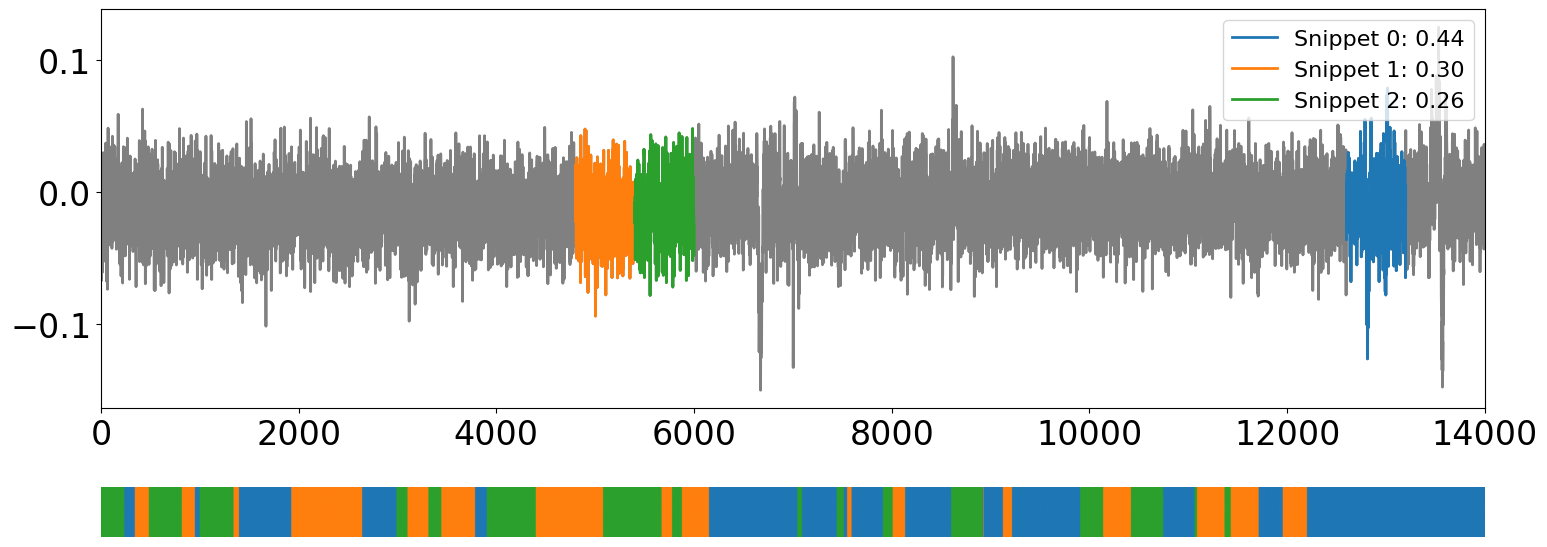

600


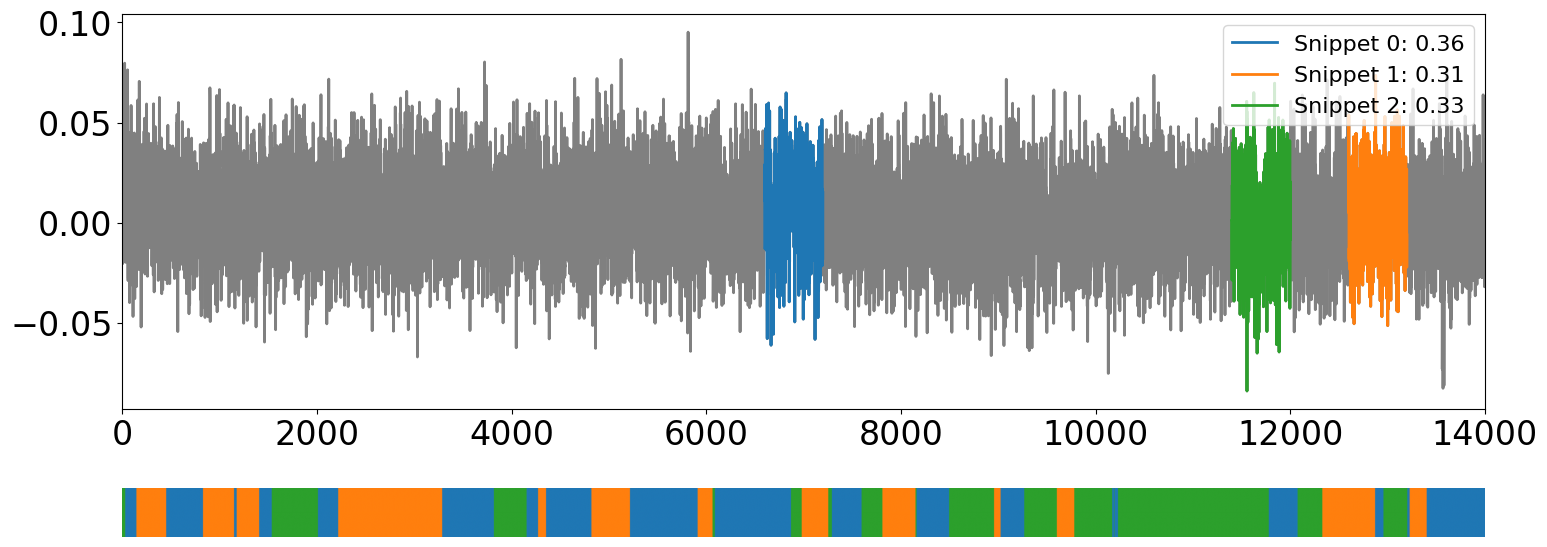

600


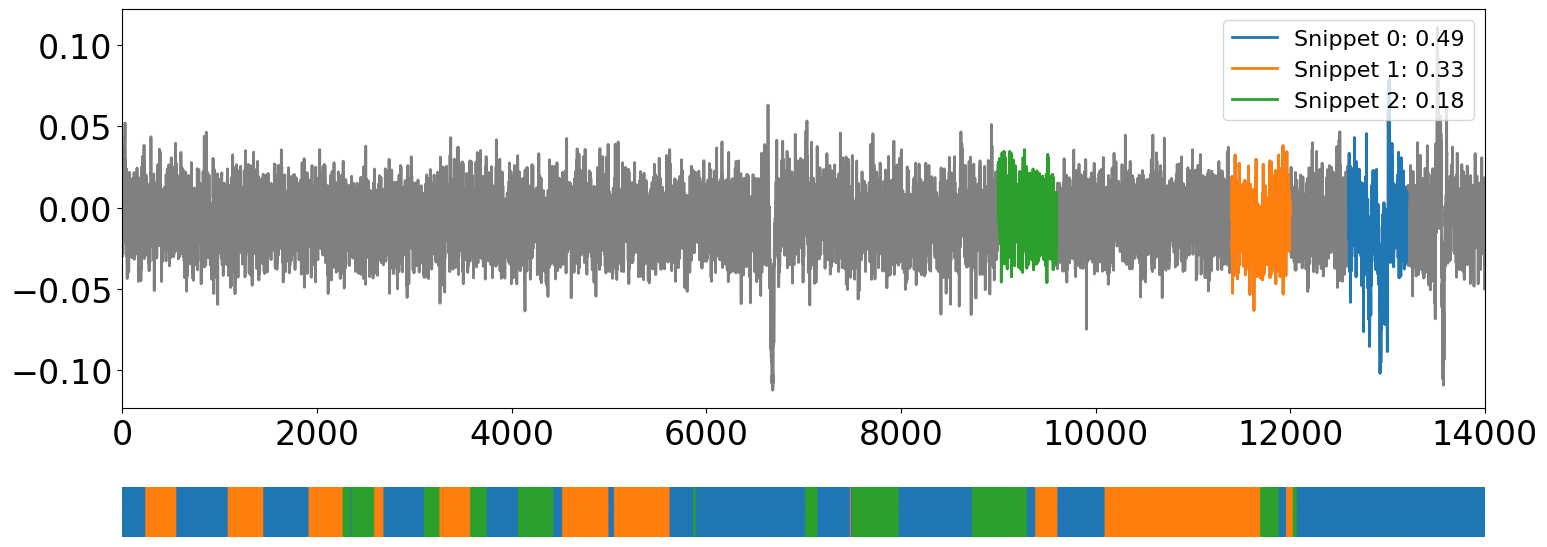

<Axes: >

In [30]:
plot_snippets(gx, snp_x)
plot_snippets(gy, snp_y)
plot_snippets(gz, snp_z)


Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [29]:
# INSERT YOUR CODE
# Оценка точности относительно activityID ---
true_activity = df_interval['activityID'].to_numpy()

accuracies = []

for lab in np.unique(final_labels):
    mask = final_labels == lab
    if mask.sum() == 0:
        continue
    main_true = np.bincount(true_activity[mask].astype(int)).argmax()
    acc = np.mean(true_activity[mask] == main_true)
    print(f"Класс {lab}: истинная активность = {main_true}, точность = {acc:.2f}")
    accuracies.append(acc)

print(f"\nСредняя точность голосования: {np.mean(accuracies):.2f}")

Класс 0: истинная активность = 9, точность = 1.00
Класс 1: истинная активность = 9, точность = 1.00

Средняя точность голосования: 1.00


❓ Проанализируйте и изложите содержательный смысл полученных результатов. Сравните полученные разметки многомерного и одномерного рядов.

Результаты:
Один сниппет мог не встретиться в интервале (или его процент слишком мал)  
Два сниппета могли покрывать одни и те же места - объединяются в один класс  
Голосование трёх осей может слить метки друг в друга  

Сравнение разметок одномерного и многомерного временных рядов:

первой части использовался временной ряд: gyro_hand_y - ось Y гироскопа на руке

Данные были взяты в интервале:  
1790–1930 секунд - 140 секунд записи
активность субъекта в этом интервале = 9 (watching TV)

Результат поиска сниппетов (Одномерная разметка)
Алгоритм STUMPY выделил:  
3 ключевых паттерна (сниппета) - каждый показан своим цветом на графике  
эти сниппеты представляют типичные циклы движения руки.  
Несмотря на то что их три, все они соответствуют одной и той же активности (ID = 9).  

Одномерная разметка оказалась абсолютно точной, но её информативность ограничена: все найденные паттерны относятся к одной активности.

Результат поиска сниппетов (Многомерная разметка)  
Сниппеты для каждой оси были найдены отдельно, а итоговая разметка строилась:
путём голосования большинством между тремя осями
То есть: каждая точка получает три метки (x-сниппет, y-сниппет, z-сниппет)   итоговая метка = та, что встречается чаще всего  

Получилось только 2 класса потому что:
1) сниппеты разных осей часто попадают в одинаковые сегменты сигнала  
2) голосование сглаживает различия между осями  
3) часть сигнала классифицируется одинаково всеми тремя осями - объединяется в один класс  
4) третий паттерн почти не встречается - исключается  


## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [ ]:
# INSERT YOUR CODE

Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

In [ ]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Какое значение $k$ является наилучшим для используемого временного ряда?